In [4]:
from google.colab import files
uploaded = files.upload()


Saving olist_customers_dataset.csv to olist_customers_dataset (1).csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv


In [5]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

master_df = orders.merge(reviews, on='order_id', how='left')
master_df = master_df.merge(customers, on='customer_id', how='left')

print(f"Master Dataset Shape: {master_df.shape}")
print(f"Duplicate Order IDs: {master_df['order_id'].duplicated().sum()}")

Master Dataset Shape: (99992, 18)
Duplicate Order IDs: 551


In [6]:
master_df = master_df.drop_duplicates(subset=['order_id'])

date_columns = ['order_estimated_delivery_date', 'order_delivered_customer_date']
for col in date_columns:
    master_df[col] = pd.to_datetime(master_df[col])

master_df = master_df.dropna(subset=['order_delivered_customer_date'])

master_df['Days_Difference'] = (master_df['order_estimated_delivery_date'] - master_df['order_delivered_customer_date']).dt.days

def classify_status(days):
    if days >= 0:
        return 'On Time'
    elif days > -5:
        return 'Late'
    else:
        return 'Super Late'

master_df['Delivery_Status'] = master_df['Days_Difference'].apply(classify_status)

print(master_df['Delivery_Status'].value_counts())

Delivery_Status
On Time       88649
Super Late     4665
Late           3162
Name: count, dtype: int64


In [7]:
state_performance = master_df.groupby('customer_state')['Delivery_Status'].value_counts(normalize=True).unstack().fillna(0)
state_performance['Late_Total %'] = (state_performance.get('Late', 0) + state_performance.get('Super Late', 0)) * 100
state_performance_sorted = state_performance.sort_values(by='Late_Total %', ascending=False)

print(state_performance_sorted[['Late_Total %']].head(10))

Delivery_Status  Late_Total %
customer_state               
AL                  23.929471
MA                  19.665272
PI                  15.966387
CE                  15.324472
SE                  15.223881
BA                  14.035627
RJ                  13.470412
TO                  12.773723
PA                  12.367865
ES                  12.230576


In [8]:
state_performance = master_df.groupby('customer_state')['Delivery_Status'].value_counts(normalize=True).unstack().fillna(0)

state_performance['Late_Total %'] = (state_performance.get('Late', 0) + state_performance.get('Super Late', 0)) * 100

state_performance_sorted = state_performance.sort_values(by='Late_Total %', ascending=False)

print(state_performance_sorted[['Late_Total %']].head(10))

Delivery_Status  Late_Total %
customer_state               
AL                  23.929471
MA                  19.665272
PI                  15.966387
CE                  15.324472
SE                  15.223881
BA                  14.035627
RJ                  13.470412
TO                  12.773723
PA                  12.367865
ES                  12.230576


In [11]:
from google.colab import files
uploaded = files.upload()

Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


In [12]:
import pandas as pd

if 'review_score' not in master_df.columns:
    reviews = pd.read_csv('olist_order_reviews_dataset.csv')
    master_df = master_df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

sentiment_analysis = master_df.groupby('Delivery_Status')['review_score'].mean()

print("Average Customer Rating by Delivery Performance:")
print(sentiment_analysis)

Average Customer Rating by Delivery Performance:
Delivery_Status
Late          3.593231
On Time       4.294358
Super Late    1.854967
Name: review_score, dtype: float64


In [13]:
import pandas as pd

products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')

products_en = products.merge(translation, on='product_category_name', how='left')

master_df = master_df.drop(columns=['product_id', 'product_category_name_english'], errors='ignore')
master_df = master_df.merge(order_items[['order_id', 'product_id']], on='order_id', how='left')
master_df = master_df.merge(products_en[['product_id', 'product_category_name_english']], on='product_id', how='left')

cat_perf = master_df.groupby('product_category_name_english')['Delivery_Status'].value_counts(normalize=True).unstack().fillna(0)
cat_perf['Late_Total %'] = (cat_perf.get('Late', 0) + cat_perf.get('Super Late', 0)) * 100

print(cat_perf.sort_values(by='Late_Total %', ascending=False).head(10))

Delivery_Status                        Late   On Time  Super Late  \
product_category_name_english                                       
home_comfort_2                     0.033333  0.833333    0.133333   
furniture_mattress_and_upholstery  0.027027  0.864865    0.108108   
audio                              0.035912  0.872928    0.091160   
fashion_underwear_beach            0.031496  0.874016    0.094488   
christmas_supplies                 0.040000  0.880000    0.080000   
books_technical                    0.060837  0.889734    0.049430   
home_confort                       0.030303  0.897436    0.072261   
construction_tools_lights          0.063123  0.900332    0.036545   
food                               0.066132  0.901804    0.032064   
electronics                        0.046904  0.902528    0.050568   

Delivery_Status                    Late_Total %  
product_category_name_english                    
home_comfort_2                        16.666667  
furniture_mattress_an

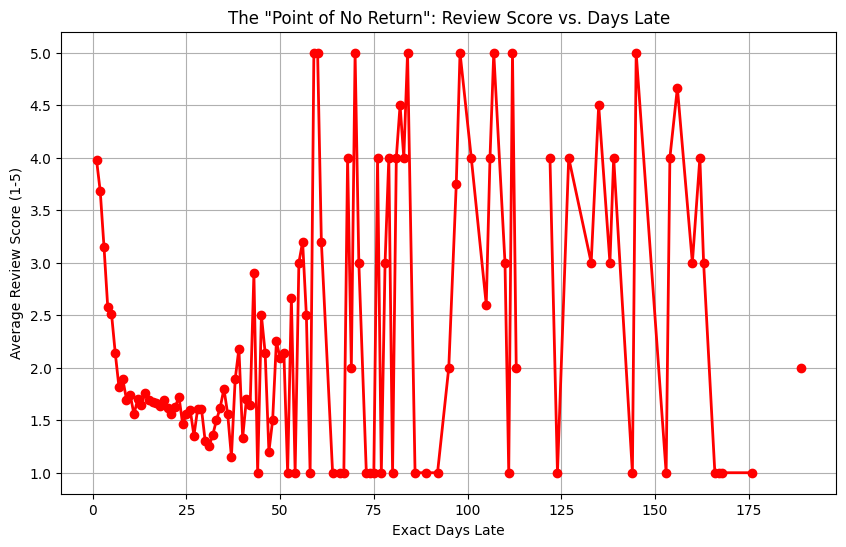

In [14]:
import matplotlib.pyplot as plt

late_orders = master_df[master_df['Days_Difference'] < 0].copy()
late_orders['Days_Late'] = late_orders['Days_Difference'].abs()

decay_data = late_orders.groupby('Days_Late')['review_score'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(decay_data['Days_Late'], decay_data['review_score'], marker='o', color='red', linewidth=2)
plt.title('The "Point of No Return": Review Score vs. Days Late')
plt.xlabel('Exact Days Late')
plt.ylabel('Average Review Score (1-5)')
plt.grid(True)
plt.show()